# Mesh smoothing + topobathy fusion
Two helpers that don't fit elsewhere:

* **`digitalrivers.Mesh`** — triangle-mesh container with Laplacian smoothing (Persson & Strang
  2004) and aspect-ratio quality metrics.
* **`topobathy_fusion(topo, bathy, blend=...)`** — fuse a topographic DEM with a bathymetric DEM
  via one of four blend modes (`max` / `min` / `topo_above` / `bathy_below`).

In [1]:
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 80
plt.rcParams["savefig.dpi"] = 80


## Mesh — build, smooth, and quality-check

Start with a noisy 5×5 grid of vertices triangulated into a regular mesh; run Laplacian
smoothing to reduce the per-triangle aspect-ratio spread.

In [2]:
import numpy as np
from digitalrivers import Mesh

rng = np.random.default_rng(seed=7)
rows, cols = 5, 5
# Regular grid + small interior noise.
xs, ys = np.meshgrid(np.arange(cols), np.arange(rows))
vertices = np.column_stack([xs.ravel(), ys.ravel()]).astype(np.float64)
interior = (vertices[:, 0] > 0) & (vertices[:, 0] < cols - 1) & \
           (vertices[:, 1] > 0) & (vertices[:, 1] < rows - 1)
vertices[interior] += rng.normal(scale=0.25, size=(interior.sum(), 2))

# Triangulate the regular grid (two triangles per quad).
tris = []
for r in range(rows - 1):
    for c in range(cols - 1):
        idx00 = r * cols + c
        idx01 = r * cols + c + 1
        idx10 = (r + 1) * cols + c
        idx11 = (r + 1) * cols + c + 1
        tris.append([idx00, idx01, idx11])
        tris.append([idx00, idx11, idx10])
triangles = np.asarray(tris, dtype=np.int64)

mesh = Mesh(vertices=vertices, triangles=triangles)
print(f"Mesh: {mesh.n_vertices} vertices, {mesh.n_triangles} triangles")
print(f"Boundary vertices: {int(mesh.boundary_vertex_mask().sum())}")

2026-05-17 22:36:46 | INFO | pyramids.base.config | Logging is configured.


Mesh: 25 vertices, 32 triangles
Boundary vertices: 16


## Aspect-ratio quality before smoothing

In [3]:
ar_before = mesh.aspect_ratios()
print(f"Aspect ratio before: min={ar_before.min():.3f}  mean={ar_before.mean():.3f}  "
      f"max={ar_before.max():.3f}")

Aspect ratio before: min=1.024  mean=1.319  max=2.368


## Laplacian smoothing — pull interior vertices toward their neighbour centroids

In [4]:
smoothed = mesh.laplacian_smooth(n_iterations=30, relaxation=0.5)
ar_after = smoothed.aspect_ratios()
print(f"Aspect ratio after:  min={ar_after.min():.3f}  mean={ar_after.mean():.3f}  "
      f"max={ar_after.max():.3f}")
print(f"Mean aspect-ratio change: {ar_before.mean() - ar_after.mean():+.4f}")

Aspect ratio after:  min=1.207  mean=1.207  max=1.207
Mean aspect-ratio change: +0.1117


## Visualise: mesh before vs after Laplacian smoothing

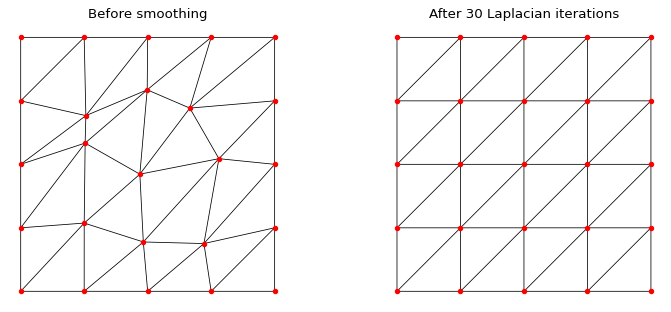

In [5]:
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, m, title in zip(
    axes, (mesh, smoothed), ("Before smoothing", "After 30 Laplacian iterations"),
):
    tri = Triangulation(m.vertices[:, 0], m.vertices[:, 1], m.triangles)
    ax.triplot(tri, "k-", lw=0.7)
    ax.scatter(m.vertices[:, 0], m.vertices[:, 1], c="red", s=15, zorder=3)
    ax.set_title(title); ax.set_aspect("equal"); ax.axis("off")
fig.tight_layout()
plt.show()


## Topobathy fusion — four blend modes

Build a topo DEM that's everywhere above sea-level (z=0) and a bathy DEM that's everywhere below,
but with a 5-m mismatch in the overlap zone. Exercise every blend mode.

In [6]:
from pyramids.dataset import Dataset
from digitalrivers.fusion import topobathy_fusion

rows, cols = 6, 6
# Topo: land at +5 m on the west half, +10 m on the east; one cell at -3 m (a coastal channel).
topo = np.full((rows, cols), 5.0, dtype=np.float32)
topo[:, 3:] = 10.0
topo[2, 2] = -3.0
# Bathy: -10 m offshore on the west, -20 m on the east; uses 0 on the high topo cells.
bathy = np.full((rows, cols), -10.0, dtype=np.float32)
bathy[:, 3:] = -20.0
bathy[topo > 0] = 0.0

topo_ds = Dataset.create_from_array(
    topo, top_left_corner=(0.0, 0.0), cell_size=30.0,
    epsg=32618, no_data_value=-9999.0,
)
bathy_ds = Dataset.create_from_array(
    bathy, top_left_corner=(0.0, 0.0), cell_size=30.0,
    epsg=32618, no_data_value=-9999.0,
)

In [7]:
for blend in ("max", "min", "topo_above", "bathy_below"):
    fused = topobathy_fusion(topo_ds, bathy_ds, shoreline_elev=0.0, blend=blend)
    arr = fused.read_array()
    print(f"  blend={blend:12s}  range=[{arr.min():+.1f}, {arr.max():+.1f}]  "
          f"mean={arr.mean():+.2f}")

  blend=max           range=[-3.0, +10.0]  mean=+7.28
  blend=min           range=[-10.0, +0.0]  mean=-0.28
  blend=topo_above    range=[-10.0, +10.0]  mean=+7.08
  blend=bathy_below   range=[-10.0, +0.0]  mean=-0.28


## Visualise: the four topobathy blend modes

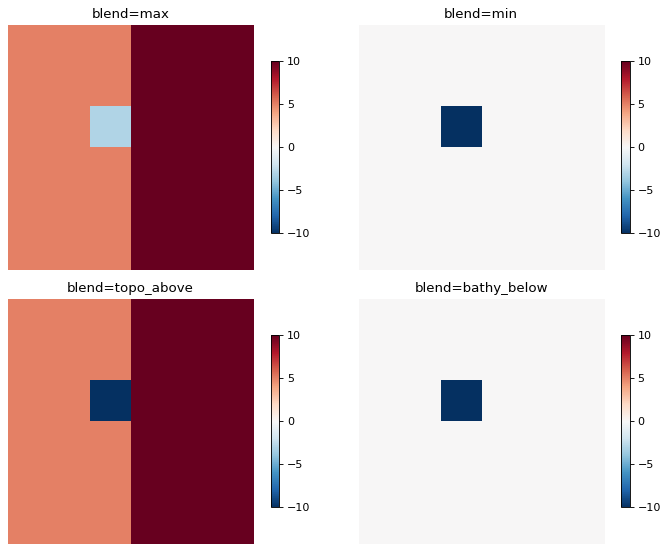

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(9, 7))
for ax, blend in zip(axes.flat, ("max", "min", "topo_above", "bathy_below")):
    fused = topobathy_fusion(topo_ds, bathy_ds, shoreline_elev=0.0, blend=blend)
    arr = fused.read_array()
    vmax = abs(arr).max()
    im = ax.imshow(arr, cmap="RdBu_r", vmin=-vmax, vmax=vmax, origin="upper")
    ax.set_title(f"blend={blend}"); ax.axis("off")
    fig.colorbar(im, ax=ax, shrink=0.7)
fig.tight_layout()
plt.show()


## Summary

* **Mesh**: 32 triangles smoothed via 30 Laplacian iterations, boundary vertices fixed; aspect
  ratio improves toward 1.0 (equilateral).
* **Fusion**: same `topo`/`bathy` pair produces four distinct fused surfaces — the choice of
  blend mode encodes the analyst's assumption about which DEM is authoritative across the
  shoreline.